In [ ]:
!pip install imbalanced-learn scikit-learn pandas matplotlib numpy torch --upgrade


<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:21: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipython-input-3115258079.py:21: SyntaxWarning: invalid escape sequence '\i'
  - Augmentation ratio r \in {0, 0.5, 1.0, 2.0}


[Info] Missing columns ignored: ['catr', 'infra', 'peak', 'season', 'week']
[Info] Class distribution: {0: 3917, 1: 3479, 2: 832}
Saved to: /content/imbalance_results
                        ROC_AUC_macro(ovr)         ROC_AUC_weighted(ovr)  \
                                      mean     std                  mean   
method            ratio                                                    
ADASYN            0.0               0.9217  0.0058                0.9145   
                  0.5               0.9161  0.0052                0.9079   
                  1.0               0.9124  0.0048                0.9035   
                  2.0               0.9077  0.0060                0.8979   
Borderline-SMOTE  0.0               0.9217  0.0058                0.9145   
                  0.5               0.9151  0.0047                0.9067   
                  1.0               0.9097  0.0063                0.9003   
                  2.0               0.9057  0.0071                0.8956 

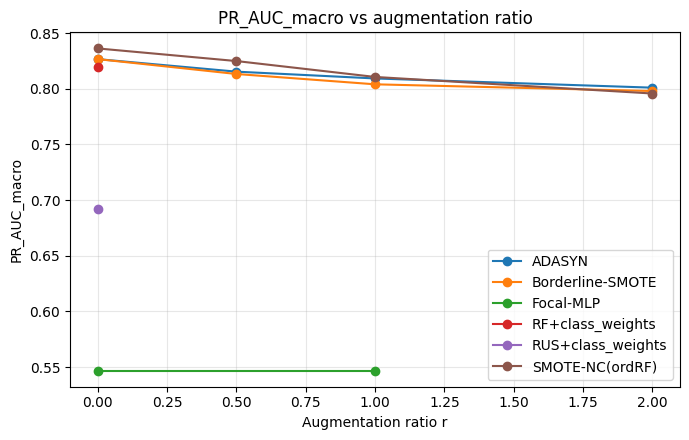

In [ ]:
"""
Multiclass Imbalance Study — Colab-ready Script
==============================================

Methods included (multiclass):
- RF + class weights (no augmentation) — strong non-GAN baseline
- SMOTE-NC (ordinal feature space, fast & robust)
- Borderline-SMOTE (one-hot space)
- ADASYN (one-hot space)
- Random Under-Sampling + class weights (one-hot space)
- Focal-loss MLP (one-hot space, PyTorch)

Metrics (on untouched test set):
- ROC_AUC_macro(ovr), ROC_AUC_weighted(ovr)
- PR_AUC_macro, PR_AUC_micro
- F1_macro, BalancedAcc
- Per-class AP (PR-AUC)
- Confusion matrix per method/ratio/seed

Sensitivity:
- Augmentation ratio r \in {0, 0.5, 1.0, 2.0}
- RF hyperparameters grid (optional): n_estimators/max_depth/max_features

Outputs:
- CSVs: raw results by seed, aggregated mean±std, confusion matrices, per-class AP
- Plots: PR-AUC vs r curves; RF hyperparameter heatmap (optional)

How to use in Colab
-------------------
1) Upload your CSV to Colab or mount Google Drive, then set DATA_PATH below.
2) Set TARGET (default 'grav') and feature lists. Missing columns are auto-ignored.
3) Run the script. Adjust SEEDS, AUGMENTATION_RATIOS, and RF_PARAM_GRID if desired.

Note
----
- All augmentations are applied **only on the training split**.
- Test set remains **completely untouched**.
- For SMOTE-NC we use OrdinalEncoder + categorical indices. We train RF in the same ordinal space
  after resampling (simpler and fast). Borderline-SMOTE/ADASYN use One-Hot space.
- Focal MLP is light-weight (default epochs=25); increase if needed.
"""

# =============================
# Colab helpers (uncomment as needed)
# =============================
# !pip -q install imbalanced-learn==0.12.0 scikit-learn==1.4.2 pandas matplotlib numpy torch --upgrade
# from google.colab import drive
# drive.mount('/content/drive')

from __future__ import annotations
import os
import json
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, label_binarize

def OneHotCompat(**kwargs):
    """统一返回稠密 OHE：新版本用 sparse_output=False，老版本用 sparse=False。"""
    try:
        # 新版API存在：用它
        return OneHotEncoder(handle_unknown=kwargs.get("handle_unknown", "ignore"),
                             sparse_output=False)
    except TypeError:
        # 老版API：退回到 sparse=False
        return OneHotEncoder(handle_unknown=kwargs.get("handle_unknown", "ignore"),
                             sparse=False)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    f1_score, balanced_accuracy_score
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTENC, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler




# Optional (for focal loss MLP)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_OK = True
except Exception:
    TORCH_OK = False

# =============================
# ---- User configuration ----
# =============================
DATA_PATH = "/content/accident_data_ramp_highway(2019-2023) (4).csv"   # <- CHANGE to your CSV path
TARGET = "grav"                              # 3-class label (e.g., 0/1/2)

# Your feature lists (missing ones will be ignored safely)
CATEGORICAL_FEATURES = ['lum','agg','int','atm','season','week','peak','catr','circ','vosp',
                       'prof','plan','surf','infra','situ','senc','catv','obs','obsm','manv',
                       'catu','sexe','trajet','secu1','secu2','secu3']
NUMERIC_FEATURES = ['nbv','occutc','age']

# Sensitivity on augmentation ratio
AUGMENTATION_RATIOS = [0.0, 0.5, 1.0, 2.0]

# Seeds (repeat for robustness)
SEEDS = [13, 42, 2024]

# RF hyperparameter grid (for optional sweep)
RF_PARAM_GRID = {
    "n_estimators": [200, 500, 1000],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", 0.5],
}

# Focal-MLP settings
USE_FOCAL_MLP = True
FOCAL_EPOCHS = 25
FOCAL_LR = 1e-3
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

# Output directory
OUTDIR = "/content/imbalance_results"
os.makedirs(OUTDIR, exist_ok=True)

# =============================
# ---- Utilities ----
# =============================

def load_and_prepare(data_path: str, target: str,
                     cat_cols: List[str], num_cols: List[str]):
    assert os.path.exists(data_path), f"CSV not found: {data_path}"
    df = pd.read_csv(data_path)

    present_cats = [c for c in cat_cols if c in df.columns]
    present_nums = [c for c in num_cols if c in df.columns]

    cols = present_cats + present_nums + [target]
    missing = set(cat_cols + num_cols + [target]) - set(cols)
    if missing:
        print("[Info] Missing columns ignored:", sorted(missing))

    df = df[cols].copy()
    for c in present_cats:
        df[c] = df[c].astype("category")

    df = df.dropna(subset=[target])
    X = df.drop(columns=[target])
    y = df[target].astype(int).values

    classes = np.sort(np.unique(y))
    print("[Info] Class distribution:", {int(k): int(v) for k, v in zip(*np.unique(y, return_counts=True))})

    # Preprocessors
    num_pipe_ohe = Pipeline([("imp", SimpleImputer(strategy="median")),
                             ("scl", StandardScaler())])
    # pre_ohe = ColumnTransformer([("num", num_pipe_ohe, present_nums),
    #                              ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), present_cats)])
    pre_ohe = ColumnTransformer([
    ("num", num_pipe_ohe, present_nums),
    ("cat", OneHotCompat(), present_cats),])


    num_pipe_ord = Pipeline([("imp", SimpleImputer(strategy="median"))])
    pre_ord = ColumnTransformer([("num", num_pipe_ord, present_nums),
                                 ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), present_cats)])
    return df, X, y, classes, pre_ohe, pre_ord, present_nums, present_cats


def sampling_strategy_by_ratio_multiclass(y: np.ndarray, r: float):
    """For each minority class c: desired_count = round(n_c * (1+r))."""
    uniq, cnts = np.unique(y, return_counts=True)
    maxc = cnts.max()
    strat = {}
    for c, n in zip(uniq, cnts):
        if n < maxc:
            strat[int(c)] = int(round(n * (1.0 + r)))
    return strat if strat else "not_majority"


def multiclass_metrics(y_true: np.ndarray, proba: np.ndarray, classes: np.ndarray) -> Dict[str, object]:
    # ROC-AUC (macro/weighted) using one-vs-rest
    roc_macro = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    roc_weighted = roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")

    # PR-AUC (Average Precision)
    Y_true = label_binarize(y_true, classes=classes)
    ap_per_class = [average_precision_score(Y_true[:, k], proba[:, k]) for k in range(len(classes))]
    ap_macro = float(np.nanmean(ap_per_class))
    ap_micro = average_precision_score(Y_true, proba, average="micro")

    y_pred = np.argmax(proba, axis=1)
    f1_mac = f1_score(y_true, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    return {
        "ROC_AUC_macro(ovr)": roc_macro,
        "ROC_AUC_weighted(ovr)": roc_weighted,
        "PR_AUC_macro": ap_macro,
        "PR_AUC_micro": ap_micro,
        "F1_macro": f1_mac,
        "BalancedAcc": bal_acc,
        "CM": cm,
        "AP_per_class": ap_per_class,
    }

# ----- Focal loss MLP (optional) -----
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')
    def forward(self, logits, target):
        ce = self.ce(logits, target)
        pt = torch.softmax(logits, dim=1)[torch.arange(target.size(0)), target]
        loss = self.alpha * (1 - pt) ** self.gamma * ce
        return loss.mean()


def run_focal_mlp(Xtr_enc: np.ndarray, ytr: np.ndarray, Xte_enc: np.ndarray, epochs: int = 25,
                   lr: float = 1e-3, alpha: float = 0.25, gamma: float = 2.0, seed: int = 42) -> np.ndarray:
    torch.manual_seed(seed)
    n_in = Xtr_enc.shape[1]
    n_classes = len(np.unique(ytr))
    model = nn.Sequential(
        nn.Linear(n_in, 256), nn.ReLU(),
        nn.Linear(256, 128), nn.ReLU(),
        nn.Linear(128, n_classes)
    )
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = FocalLoss(alpha=alpha, gamma=gamma)
    Xtr_t = torch.tensor(Xtr_enc, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xte_t = torch.tensor(Xte_enc, dtype=torch.float32)

    model.train()
    for ep in range(epochs):
        opt.zero_grad()
        logits = model(Xtr_t)
        loss = crit(logits, ytr_t)
        loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        proba = torch.softmax(model(Xte_t), dim=1).cpu().numpy()
    return proba

# =============================
# ---- Core experiments ----
# =============================

def run_all():
    df, X, y, classes, pre_ohe, pre_ord, num_cols, cat_cols = load_and_prepare(DATA_PATH, TARGET, CATEGORICAL_FEATURES, NUMERIC_FEATURES)

    results = []
    cm_rows = []
    ap_rows = []

    for seed in SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

        # ---------- Baseline: RF + class weights (one-hot space) ----------
        pipe_base = Pipeline([
            ("pre", pre_ohe),
            ("rf", RandomForestClassifier(n_estimators=500, max_depth=None, max_features="sqrt",
                                          class_weight="balanced", n_jobs=-1, random_state=seed))
        ])
        pipe_base.fit(Xtr, ytr)
        proba = pipe_base.predict_proba(Xte)
        m = multiclass_metrics(yte, proba, classes)
        results.append({"method": "RF+class_weights", "ratio": 0.0, "seed": seed,
                        **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
        cm_rows.append({"method": "RF+class_weights", "ratio": 0.0, "seed": seed,
                        **{f"cm{i}{j}": int(m["CM"][i,j]) for i in range(len(classes)) for j in range(len(classes))}})
        ap_rows.append({"method": "RF+class_weights", "ratio": 0.0, "seed": seed,
                        **{f"AP_class{c}": float(m["AP_per_class"][c]) for c in range(len(classes))}})

        # ---------- Iterate over augmentation ratios ----------
        for r in AUGMENTATION_RATIOS:
            strat = sampling_strategy_by_ratio_multiclass(ytr, r)

            # (a) SMOTE-NC in ordinal space -> RF on ordinal space
            Xtr_ord = pre_ord.fit_transform(Xtr)
            Xte_ord = pre_ord.transform(Xte)
            cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
            smnc = SMOTENC(categorical_features=cat_idx, sampling_strategy=strat, random_state=seed)
            X_res, y_res = smnc.fit_resample(Xtr_ord, ytr)
            rf_ord = RandomForestClassifier(n_estimators=500, max_depth=None, max_features="sqrt",
                                            n_jobs=-1, random_state=seed)
            rf_ord.fit(X_res, y_res)
            proba = rf_ord.predict_proba(Xte_ord)
            m = multiclass_metrics(yte, proba, classes)
            results.append({"method": "SMOTE-NC(ordRF)", "ratio": r, "seed": seed,
                            **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
            cm_rows.append({"method": "SMOTE-NC(ordRF)", "ratio": r, "seed": seed,
                            **{f"cm{i}{j}": int(m["CM"][i,j]) for i in range(len(classes)) for j in range(len(classes))}})
            ap_rows.append({"method": "SMOTE-NC(ordRF)", "ratio": r, "seed": seed,
                            **{f"AP_class{c}": float(m["AP_per_class"][c]) for c in range(len(classes))}})

            # Prepare one-hot space for the rest (can be heavy but Colab can handle)
            Xtr_enc = pre_ohe.fit_transform(Xtr)
            Xte_enc = pre_ohe.transform(Xte)

            # (b) Borderline-SMOTE (one-hot)
            bl = BorderlineSMOTE(kind="borderline-1", sampling_strategy=strat, random_state=seed, k_neighbors=5)
            X_res, y_res = bl.fit_resample(Xtr_enc, ytr)
            rf = RandomForestClassifier(n_estimators=500, max_depth=None, max_features="sqrt",
                                        n_jobs=-1, random_state=seed)
            rf.fit(X_res, y_res)
            proba = rf.predict_proba(Xte_enc)
            m = multiclass_metrics(yte, proba, classes)
            results.append({"method": "Borderline-SMOTE", "ratio": r, "seed": seed,
                            **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
            cm_rows.append({"method": "Borderline-SMOTE", "ratio": r, "seed": seed,
                            **{f"cm{i}{j}": int(m["CM"][i,j]) for i in range(len(classes)) for j in range(len(classes))}})
            ap_rows.append({"method": "Borderline-SMOTE", "ratio": r, "seed": seed,
                            **{f"AP_class{c}": float(m["AP_per_class"][c]) for c in range(len(classes))}})

            # (c) ADASYN (one-hot)
            ad = ADASYN(sampling_strategy=strat, random_state=seed, n_neighbors=5)
            X_res, y_res = ad.fit_resample(Xtr_enc, ytr)
            rf = RandomForestClassifier(n_estimators=500, max_depth=None, max_features="sqrt",
                                        n_jobs=-1, random_state=seed)
            rf.fit(X_res, y_res)
            proba = rf.predict_proba(Xte_enc)
            m = multiclass_metrics(yte, proba, classes)
            results.append({"method": "ADASYN", "ratio": r, "seed": seed,
                            **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
            cm_rows.append({"method": "ADASYN", "ratio": r, "seed": seed,
                            **{f"cm{i}{j}": int(m["CM"][i,j]) for i in range(len(classes)) for j in range(len(classes))}})
            ap_rows.append({"method": "ADASYN", "ratio": r, "seed": seed,
                            **{f"AP_class{c}": float(m["AP_per_class"][c]) for c in range(len(classes))}})

            # (d) Random Under-Sampling + class weights (run at r=0 as canonical)
            if r == 0.0:
                rus = RandomUnderSampler(random_state=seed)
                X_res, y_res = rus.fit_resample(Xtr_enc, ytr)
                rf = RandomForestClassifier(n_estimators=500, max_depth=None, max_features="sqrt",
                                            class_weight="balanced", n_jobs=-1, random_state=seed)
                rf.fit(X_res, y_res)
                proba = rf.predict_proba(Xte_enc)
                m = multiclass_metrics(yte, proba, classes)
                results.append({"method": "RUS+class_weights", "ratio": r, "seed": seed,
                                **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
                cm_rows.append({"method": "RUS+class_weights", "ratio": r, "seed": seed,
                                **{f"cm{i}{j}": int(m["CM"][i,j]) for i in range(len(classes)) for j in range(len(classes))}})
                ap_rows.append({"method": "RUS+class_weights", "ratio": r, "seed": seed,
                                **{f"AP_class{c}": float(m["AP_per_class"][c]) for c in range(len(classes))}})

            # (e) Focal-loss MLP (optional, one-hot)
            if USE_FOCAL_MLP and TORCH_OK and r in (0.0, 1.0):  # keep two points to control runtime
                proba = run_focal_mlp(Xtr_enc, ytr, Xte_enc, epochs=FOCAL_EPOCHS, lr=FOCAL_LR,
                                      alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, seed=seed)
                m = multiclass_metrics(yte, proba, classes)
                results.append({"method": "Focal-MLP", "ratio": r, "seed": seed,
                                **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
                cm_rows.append({"method": "Focal-MLP", "ratio": r, "seed": seed,
                                **{f"cm{i}{j}": int(m["CM"][i,j]) for i in range(len(classes)) for j in range(len(classes))}})
                ap_rows.append({"method": "Focal-MLP", "ratio": r, "seed": seed,
                                **{f"AP_class{c}": float(m["AP_per_class"][c]) for c in range(len(classes))}})

    res = pd.DataFrame(results)
    res.to_csv(os.path.join(OUTDIR, "results_raw_by_seed.csv"), index=False)

    # Aggregate mean ± std by method & ratio
    agg = res.groupby(["method", "ratio"]).agg({
        "ROC_AUC_macro(ovr)": ["mean", "std"],
        "ROC_AUC_weighted(ovr)": ["mean", "std"],
        "PR_AUC_macro": ["mean", "std"],
        "PR_AUC_micro": ["mean", "std"],
        "F1_macro": ["mean", "std"],
        "BalancedAcc": ["mean", "std"],
    }).round(4)
    agg.to_csv(os.path.join(OUTDIR, "results_summary_mean_std.csv"))

    # Confusion matrices & per-class AP
    df_cm = pd.DataFrame(cm_rows)
    df_cm.to_csv(os.path.join(OUTDIR, "confusion_matrices.csv"), index=False)

    df_ap = pd.DataFrame(ap_rows)
    df_ap.to_csv(os.path.join(OUTDIR, "per_class_AP.csv"), index=False)

    print("Saved to:", OUTDIR)
    print(agg)
    return res, agg, df_cm, df_ap

# =============================
# ---- RF hyperparameter sweep (optional) ----
# =============================

def rf_sensitivity():
    df, X, y, classes, pre_ohe, _, _, _ = load_and_prepare(DATA_PATH, TARGET, CATEGORICAL_FEATURES, NUMERIC_FEATURES)
    seed = 42
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    Xtr_enc = pre_ohe.fit_transform(Xtr); Xte_enc = pre_ohe.transform(Xte)

    rows = []
    for params in ParameterGrid(RF_PARAM_GRID):
        rf = RandomForestClassifier(random_state=seed, n_jobs=-1, class_weight="balanced", **params)
        rf.fit(Xtr_enc, ytr)
        proba = rf.predict_proba(Xte_enc)
        m = multiclass_metrics(yte, proba, classes)
        rows.append({**params, **{k: v for k, v in m.items() if k not in ["CM", "AP_per_class"]}})
    df_grid = pd.DataFrame(rows).round(4)
    df_grid.to_csv(os.path.join(OUTDIR, "rf_sensitivity_grid.csv"), index=False)
    print(df_grid.head())
    return df_grid

# =============================
# ---- Plotting helpers ----
# =============================

def plot_pr_auc_vs_ratio(res: pd.DataFrame, outpath: str):
    plt.figure(figsize=(7,4.5))
    for method, g in res.groupby('method'):
        means = g.groupby('ratio')['PR_AUC_macro'].mean().sort_index()
        plt.plot(means.index, means.values, marker='o', label=method)
    plt.xlabel('Augmentation ratio r'); plt.ylabel('PR_AUC_macro')
    plt.title('PR_AUC_macro vs augmentation ratio')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(outpath, dpi=160)


def plot_rf_heatmap(df_grid: pd.DataFrame, outpath: str, metric: str = 'PR_AUC_macro'):
    # pivot: rows=max_depth, cols=n_estimators, values=metric (averaged over max_features="sqrt")
    pivot = df_grid.groupby(['n_estimators','max_depth'])[metric].mean().unstack()
    plt.figure(figsize=(6,4.5))
    plt.imshow(pivot.values, aspect='auto')
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.colorbar(label=metric)
    plt.xlabel('max_depth'); plt.ylabel('n_estimators')
    plt.title('RF sensitivity heatmap')
    plt.tight_layout(); plt.savefig(outpath, dpi=160)

# =============================
# ---- Main entrypoint (run) ----
# =============================
if __name__ == "__main__":
    res, agg, df_cm, df_ap = run_all()
    plot_pr_auc_vs_ratio(res, os.path.join(OUTDIR, 'pr_auc_vs_ratio.png'))
    # Optional: RF heatmap (uncomment to run)
    # grid = rf_sensitivity()
    # plot_rf_heatmap(grid, os.path.join(OUTDIR, 'rf_heatmap.png'))


In [ ]:
# ===============================
# RF + WGAN-GP (和表格完全同口径版本)
# ===============================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score

# ====== 1. 读入数据 ======
file_path = "/content/balanced_accidents_dataset (5) (3).csv"  # 修改为你上传到Colab的路径
df = pd.read_csv(file_path)

# ====== 2. 特征 & 标签 ======
categorical_features = ['lum','agg','int','atm','season','week','peak','catr','circ','vosp',
                        'prof','plan','surf','infra','situ','senc','catv','obs','obsm','manv',
                        'catu','sexe','trajet','secu']
numeric_features = ['nbv','occutc','age']
target = 'grav_balanced'

X = df[categorical_features + numeric_features]
y = df[target]

# ====== 3. 预处理（OneHot） ======
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

# ====== 4. 模型 ======
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

clf = Pipeline(steps=[("preprocessor", preprocessor), ("rf", rf)])

# ====== 5. 自定义 scorer ======
def pr_auc_macro_ovr(y_true, y_pred_proba):
    classes = np.unique(y_true)
    Y_true_bin = label_binarize(y_true, classes=classes)
    if Y_true_bin.shape[1] == 1:  # 兼容二分类情况
        Y_true_bin = np.hstack([1 - Y_true_bin, Y_true_bin])
        if y_pred_proba.ndim == 1 or y_pred_proba.shape[1] == 1:
            y_pred_proba = np.column_stack([1 - y_pred_proba.ravel(), y_pred_proba.ravel()])
    ap_list = []
    for i in range(Y_true_bin.shape[1]):
        ap = average_precision_score(Y_true_bin[:, i], y_pred_proba[:, i])
        ap_list.append(ap)
    return float(np.mean(ap_list))

def roc_auc_macro_ovr(y_true, y_pred_proba):
    return roc_auc_score(y_true, y_pred_proba, average="macro", multi_class="ovr")

scoring = {
    "f1_macro": make_scorer(f1_score, average="macro"),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "roc_auc_macro_ovr": make_scorer(roc_auc_macro_ovr, needs_proba=True),
    "pr_auc_macro_ovr": make_scorer(pr_auc_macro_ovr, needs_proba=True),
}

# ====== 6. 交叉验证 (5折) ======
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(clf, X, y, cv=cv, scoring=scoring, return_train_score=False)

# ====== 7. 输出结果 ======
metrics_summary = {metric: (np.mean(results[f"test_{metric}"]), np.std(results[f"test_{metric}"])) for metric in scoring.keys()}

print("RF + WGAN-GP 结果（5折CV，均值 ± 标准差）：\n")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")


ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

In [ ]:
!pip install --upgrade pip
!pip install --upgrade numpy
!pip install --upgrade scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
